In [1]:
# %% [Cell 1] Setup
# ------------------------------------------------------------
!git clone https://github.com/syediu/nanobench-iros2026.git
!pip install -q numpy pandas matplotlib

# Upload swift_physics_headless.py to Colab first (left sidebar -> Files
# -> upload), or mount Drive and adjust the path below.
import sys
sys.path.insert(0, "/content")  # wherever swift_physics_headless.py lives

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

import swift_physics_headless as phys

Cloning into 'nanobench-iros2026'...
remote: Enumerating objects: 375, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 375 (delta 0), reused 3 (delta 0), pack-reused 372 (from 1)
Receiving objects: 100% (375/375), 112.82 MiB | 19.00 MiB/s, done.
Resolving deltas: 100% (49/49), done.
Updating files: 100% (384/384), done.


In [2]:
# %% [Cell 2] Locate a trajectory CSV and inspect its columns
# ------------------------------------------------------------
# NOTE: exact folder layout / column names are unverified from this
# environment (couldn't reach github.com to inspect the repo directly).
# Run this cell first and READ the printed column list before assuming
# any of the names below are correct -- adjust COLMAP in Cell 3 to match.

candidates = glob.glob("/content/nanobench-iros2026/**/*.csv", recursive=True)
print(f"Found {len(candidates)} CSVs")
for c in candidates[:20]:
    print(" ", c)

# Prefer a Category A (multisine) file for the first validation pass --
# it's the excitation trajectory, cleanest single-flight test.
traj_path = next((c for c in candidates if "multisine" in c.lower()), candidates[0])
print("\nUsing:", traj_path)

df = pd.read_csv(traj_path)
print(df.columns.tolist())
df.head()

Found 152 CSVs
  /content/nanobench-iros2026/benchmarks/results/tables/task3_trefoil_table.csv
  /content/nanobench-iros2026/benchmarks/results/tables/task3_evaluation_table.csv
  /content/nanobench-iros2026/benchmarks/results/tables/task2_performance_table.csv
  /content/nanobench-iros2026/benchmarks/results/tables/task1_model_comparison_table.csv
  /content/nanobench-iros2026/benchmarks/results/tables/dataset_summary_table.csv
  /content/nanobench-iros2026/benchmarks/task2_control/results/tables/table_task2_classical_per_run.csv
  /content/nanobench-iros2026/benchmarks/task2_control/results/tables/table_task2_per_trajectory_type.csv
  /content/nanobench-iros2026/benchmarks/task2_control/results/tables/table_task2_closed_loop_main.csv
  /content/nanobench-iros2026/benchmarks/task2_control/results/tables/table_task2_combined_comparison.csv
  /content/nanobench-iros2026/benchmarks/task2_control/results/tables/table_task2_classical_speed_summary.csv
  /content/nanobench-iros2026/benchmar

,t,px,py,pz,qx,qy,qz,qw,roll,pitch,...,att_stateEstimate_qw,sp_ctrltarget_x,sp_ctrltarget_y,sp_ctrltarget_z,sp_ctrltarget_yaw,pid_controller_roll,pid_controller_pitch,pid_controller_yaw,pid_controller_cmd_thrust,pwr_pm_vbat
0,1.772459e+09,0.014899,0.007783,0.058204,-0.002671,0.010448,0.017713,0.999785,-0.004972,0.020987,...,0.999912,0.0,0.0,0.0,0.0,0.0,0.0,1.498512,0.0,4.017009
1,1.772459e+09,0.014914,0.007777,0.058205,-0.002656,0.010522,0.017801,0.999783,-0.004937,0.021135,...,0.999912,0.0,0.0,0.0,0.0,0.0,0.0,1.498285,0.0,4.017009
2,1.772459e+09,0.014922,0.007776,0.058212,-0.002776,0.010482,0.017877,0.999781,-0.005177,0.021060,...,0.999912,0.0,0.0,0.0,0.0,0.0,0.0,1.497901,0.0,4.017009
3,1.772459e+09,0.014924,0.007765,0.058203,-0.002859,0.010295,0.017717,0.999786,-0.005354,0.020688,...,0.999912,0.0,0.0,0.0,0.0,0.0,0.0,1.497467,0.0,4.017009
4,1.772459e+09,0.014919,0.007766,0.058206,-0.002949,0.010486,0.017671,0.999785,-0.005528,0.021073,...,0.999912,0.0,0.0,0.0,0.0,0.0,0.0,1.496497,0.0,4.017009


In [3]:
# %% [Cell 2b] Check motor command range BEFORE assuming PWM [0,65535]
# ------------------------------------------------------------
print(df[["motor_motor_m1", "motor_motor_m2", "motor_motor_m3", "motor_motor_m4"]].describe())
print(df["pwr_pm_vbat"].describe())

       motor_motor_m1  motor_motor_m2  motor_motor_m3  motor_motor_m4
count     7207.000000     7207.000000     7207.000000     7207.000000
mean     54131.481770    51757.598458    53444.539571    55588.291170
std      15959.466027    15373.619419    15721.910284    16366.531466
min          0.000000        0.000000        0.000000        0.000000
25%      55344.490080    52341.737004    54476.767914    56612.133806
50%      58387.534618    55606.309044    57635.141393    59990.418601
75%      61254.213451    58834.589452    60476.065939    63224.167629
max      65535.000000    65535.000000    65535.000000    65535.000000
count    7207.000000
mean        3.396823
std         0.163432
min         3.205250
25%         3.301433
50%         3.354282
75%         3.427465
max         4.022224
Name: pwr_pm_vbat, dtype: float64


In [4]:
# %% [Cell 3] Column mapping -- confirmed against real NanoBench columns
# ------------------------------------------------------------
# Real columns (from your Cell 2 run):
#   t, px, py, pz, qx, qy, qz, qw, roll, pitch, yaw, vx, vy, vz,
#   wx_vicon, wy_vicon, wz_vicon, imu_acc_x/y/z, imu_gyro_x/y/z,
#   motor_motor_m1..m4, est_stateEstimate_*, att_stateEstimate_*,
#   sp_ctrltarget_*, pid_controller_roll/pitch/yaw/cmd_thrust, pwr_pm_vbat
#
# IMPORTANT: NanoBench's quaternion columns are SCALAR-LAST (qx,qy,qz,qw),
# but your physics code's quat2rotm_manual / quat_mult expect SCALAR-FIRST
# (w,x,y,z). We reorder immediately below -- do not just rename qw->qw.

COLMAP = {
    "t":  "t",
    "px": "px", "py": "py", "pz": "pz",
    "vx": "vx", "vy": "vy", "vz": "vz",
    "u1": "motor_motor_m1", "u2": "motor_motor_m2",
    "u3": "motor_motor_m3", "u4": "motor_motor_m4",
    "vbat": "pwr_pm_vbat",
    "gx": "imu_gyro_x", "gy": "imu_gyro_y", "gz": "imu_gyro_z",
}

def col(name):
    c = COLMAP[name]
    if c not in df.columns:
        raise KeyError(f"Column '{c}' (mapped from '{name}') not found. "
                        f"Available columns: {df.columns.tolist()}")
    return df[c].to_numpy()

t = col("t")
dt = float(np.median(np.diff(t)))
print(f"Inferred dt = {dt:.5f} s  ({1/dt:.1f} Hz)")

p_gt = np.column_stack([col("px"), col("py"), col("pz")])

# Reorder scalar-last (qx,qy,qz,qw) -> scalar-first (qw,qx,qy,qz)
qx, qy, qz, qw = df["qx"].to_numpy(), df["qy"].to_numpy(), df["qz"].to_numpy(), df["qw"].to_numpy()
q_gt = np.column_stack([qw, qx, qy, qz])

v_gt = np.column_stack([col("vx"), col("vy"), col("vz")])
omega_gt = np.column_stack([col("gx"), col("gy"), col("gz")])  # body-frame, IMU gyro

pwm_raw = np.column_stack([col("u1"), col("u2"), col("u3"), col("u4")])

# Normalize motor commands to [0,1] based on the ACTUAL observed range
# (checked in Cell 2b) rather than assuming 65535 blindly.
pwm_max_observed = pwm_raw.max()
print(f"Observed motor command range: [{pwm_raw.min():.3f}, {pwm_max_observed:.3f}]")
if pwm_max_observed > 2.0:
    # looks like raw PWM-scale values
    cmd_sequence = pwm_raw / 65535.0
    print("Treating motor columns as raw PWM [0, 65535] -> normalizing by 65535.")
else:
    # already normalized (e.g. [0,1] thrust fraction)
    cmd_sequence = pwm_raw
    print("Motor columns already look normalized -- using as-is.")

vbat = col("vbat")

Inferred dt = 0.01000 s  (100.0 Hz)
Observed motor command range: [0.000, 65535.000]
Treating motor columns as raw PWM [0, 65535] -> normalizing by 65535.


In [18]:
# %% [Cell 4] Initial state (from first Vicon sample) + params
# ------------------------------------------------------------
initial_state = {
    "p_WB": p_gt[0].copy(),
    "q_WB": q_gt[0].copy(),
    "v_WB": v_gt[0].copy(),
    "omega_B": omega_gt[0].copy(),   # real IMU gyro reading at t=0, not zero
    "Omega": np.zeros(4),
    "U_bat": float(vbat[0]),
}

# Use the "nanobench" preset: m, J, c_l (k_F), c_d (k_M) are now the
# EXACT values NanoBench's own physics baseline uses (m, J measured/
# sourced by NanoBench itself; c_l/c_d are Busetto et al. 2025's fitted
# k_F/k_M on the same airframe class). This is as close to "identical
# parameters" as the published sources allow -- see chat notes for what
# is still NOT independently confirmed (arm length, k_mot, PID gains,
# Stage-7 aero coefficients remain your own values either way).
params = phys.PARAMS_NANOBENCH

In [20]:
import importlib
import swift_physics_headless
importlib.reload(swift_physics_headless)
phys = swift_physics_headless

In [21]:
# %% [Cell 4b] Sanity checks BEFORE running the simulation
# ------------------------------------------------------------
# Check 1: gyro units. If these values are routinely > ~20 in magnitude,
# they're almost certainly degrees/sec, not rad/s, and need conversion.
print("First 5 gyro readings (should be small if rad/s):")
print(omega_gt[:5])
print(f"Gyro magnitude range: [{np.abs(omega_gt).min():.3f}, {np.abs(omega_gt).max():.3f}]")

# If the above shows large values (tens/hundreds), uncomment this line:
# omega_gt = np.radians(omega_gt)
# initial_state["omega_B"] = omega_gt[0].copy()

# Check 2: sanity-check the ESC/battery model's Omega_ss output over the
# actual command range in this trajectory -- confirms Stage 2 isn't
# already producing nonsense before we even integrate.
_test_Omega_ss, _ = phys.esc_battery_model(
    cmd_sequence[0], vbat[0], np.zeros(4),
    params["eta"], params["battery_coeffs"], dt, params["c_d"])
print(f"\nOmega_ss at first sample (cmd={cmd_sequence[0]}, U_bat={vbat[0]:.2f}): {_test_Omega_ss}")
print("Sanity range for a nano-quad motor is roughly a few hundred to a few thousand rad/s.")
print("If this is negative, or >1e4, or wildly inconsistent across the 4 motors, Stage 2 is the problem.")

First 5 gyro readings (should be small if rad/s):
[[ 0.00292496 -0.00366887  0.00170901]
 [ 0.00251218 -0.00354952 -0.00086461]
 [ 0.0014414   0.0008505  -0.00252663]
 [ 0.001335    0.00184288  0.00078926]
 [-0.00021528  0.00238044  0.00252443]]
Gyro magnitude range: [0.000, 13.165]

Omega_ss at first sample (cmd=[0. 0. 0. 0.], U_bat=4.02): [0. 0. 0. 0.]
Sanity range for a nano-quad motor is roughly a few hundred to a few thousand rad/s.
If this is negative, or >1e4, or wildly inconsistent across the 4 motors, Stage 2 is the problem.


In [22]:
# %% [Cell 5] Run open-loop simulation
# ------------------------------------------------------------
sim = phys.simulate_open_loop(
    cmd_sequence=cmd_sequence,
    dt=dt,
    initial_state=initial_state,
    params=params,
    U_bat_sequence=vbat,   # pass None to let the battery model evolve itself
)

p_pred = sim["p_WB"]
v_pred = sim["v_WB"]
q_pred = sim["q_WB"]

In [23]:
# %% [Cell 6] Error metrics (mirrors the paper's MAE-at-horizon style)
# ------------------------------------------------------------
def quat_angle_error(q1, q2):
    """2*atan2(|qv|, qw) of the relative quaternion q1^-1 * q2, per row."""
    def conj(q):
        return np.column_stack([q[:, 0], -q[:, 1], -q[:, 2], -q[:, 3]])
    def qmul(a, b):
        w1, x1, y1, z1 = a[:, 0], a[:, 1], a[:, 2], a[:, 3]
        w2, x2, y2, z2 = b[:, 0], b[:, 1], b[:, 2], b[:, 3]
        return np.column_stack([
            w1*w2 - x1*x2 - y1*y2 - z1*z2,
            w1*x2 + x1*w2 + y1*z2 - z1*y2,
            w1*y2 - x1*z2 + y1*w2 + z1*x2,
            w1*z2 + x1*y2 - y1*x2 + z1*w2,
        ])
    rel = qmul(conj(q1), q2)
    qv_norm = np.linalg.norm(rel[:, 1:], axis=1)
    return 2 * np.arctan2(qv_norm, np.abs(rel[:, 0]))

pos_err = np.linalg.norm(p_pred - p_gt, axis=1)
vel_err = np.linalg.norm(v_pred - v_gt, axis=1)
att_err = quat_angle_error(q_gt, q_pred)

print(f"Position error  -- mean: {pos_err.mean()*1000:.1f} mm, "
      f"final: {pos_err[-1]*1000:.1f} mm")
print(f"Velocity error  -- mean: {vel_err.mean():.3f} m/s, "
      f"final: {vel_err[-1]:.3f} m/s")
print(f"Attitude error  -- mean: {np.degrees(att_err).mean():.2f} deg, "
      f"final: {np.degrees(att_err[-1]):.2f} deg")

Position error  -- mean: 1252866.8 mm, final: 2398497.4 mm
Velocity error  -- mean: 41.726 m/s, final: 21.124 m/s
Attitude error  -- mean: 116.83 deg, final: 61.11 deg


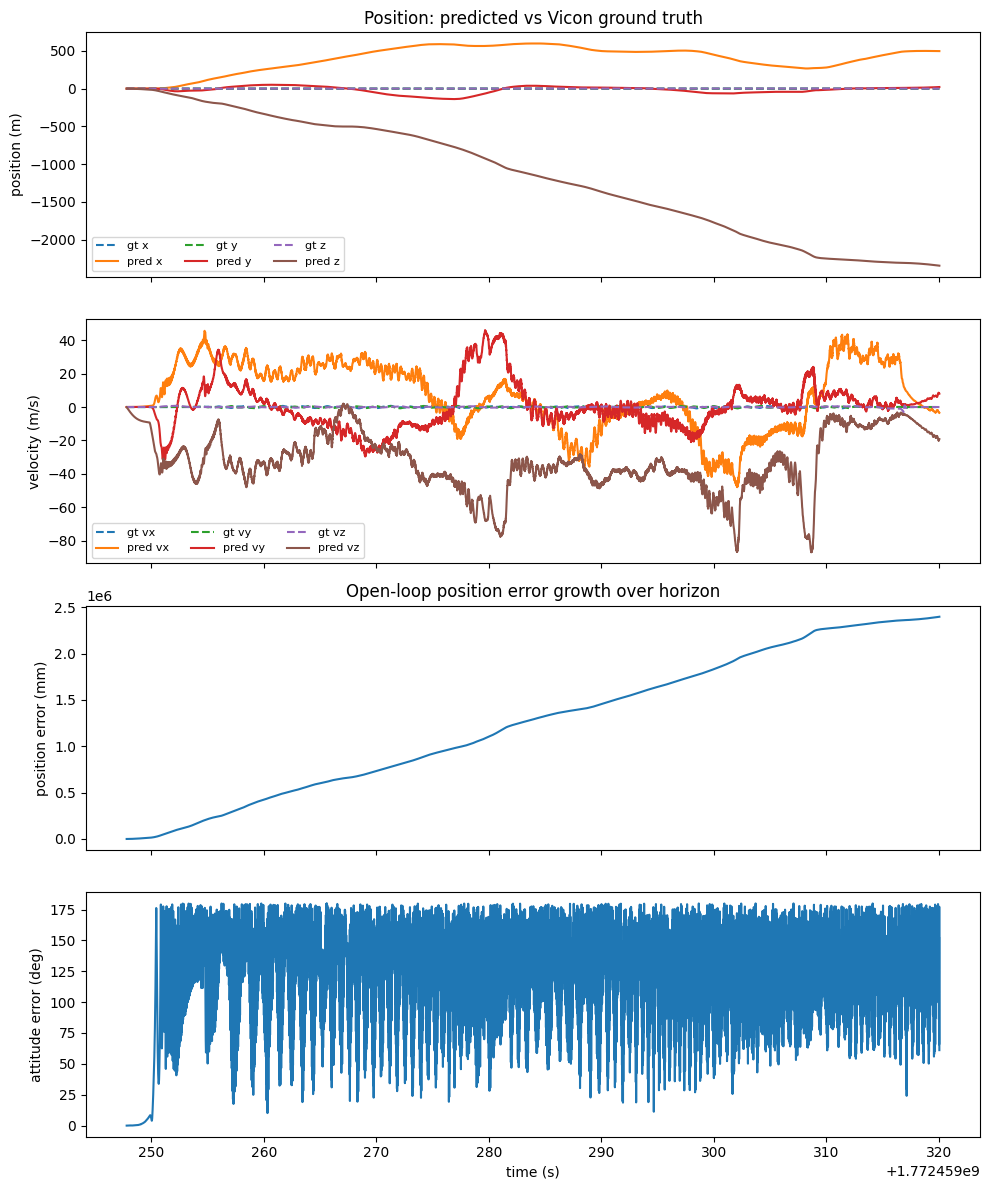

In [24]:
# %% [Cell 7] Plots -- predicted vs ground truth
# ------------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

labels = ["x", "y", "z"]
for i in range(3):
    axes[0].plot(t, p_gt[:, i], "--", label=f"gt {labels[i]}")
    axes[0].plot(t, p_pred[:, i], label=f"pred {labels[i]}")
axes[0].set_ylabel("position (m)")
axes[0].legend(ncol=3, fontsize=8)
axes[0].set_title("Position: predicted vs Vicon ground truth")

for i in range(3):
    axes[1].plot(t, v_gt[:, i], "--", label=f"gt v{labels[i]}")
    axes[1].plot(t, v_pred[:, i], label=f"pred v{labels[i]}")
axes[1].set_ylabel("velocity (m/s)")
axes[1].legend(ncol=3, fontsize=8)

axes[2].plot(t, pos_err * 1000)
axes[2].set_ylabel("position error (mm)")
axes[2].set_title("Open-loop position error growth over horizon")

axes[3].plot(t, np.degrees(att_err))
axes[3].set_ylabel("attitude error (deg)")
axes[3].set_xlabel("time (s)")

plt.tight_layout()
plt.savefig("/content/validation_plot.png", dpi=150)
plt.show()

/content/swift_physics_headless.py:135: RuntimeWarning: overflow encountered in scalar power
  vy*Omega_bar_sq, vy*abs(vy)*Omega_bar_sq])
/content/swift_physics_headless.py:138: RuntimeWarning: overflow encountered in scalar multiply
  tau_z = tauz_coeffs @ np.array([vx, vy])
/content/swift_physics_headless.py:139: RuntimeWarning: overflow encountered in scalar multiply
  
/content/swift_physics_headless.py:140: RuntimeWarning: overflow encountered in scalar multiply
  f_aero = np.array([f_x, f_y, f_z])
/content/swift_physics_headless.py:140: RuntimeWarning: invalid value encountered in matmul
  f_aero = np.array([f_x, f_y, f_z])
/content/swift_physics_headless.py:143: RuntimeWarning: overflow encountered in scalar multiply
  
/content/swift_physics_headless.py:144: RuntimeWarning: overflow encountered in scalar multiply
  
/content/swift_physics_headless.py:143: RuntimeWarning: invalid value encountered in matmul
  
/content/swift_physics_headless.py:145: RuntimeWarning: overflow enco

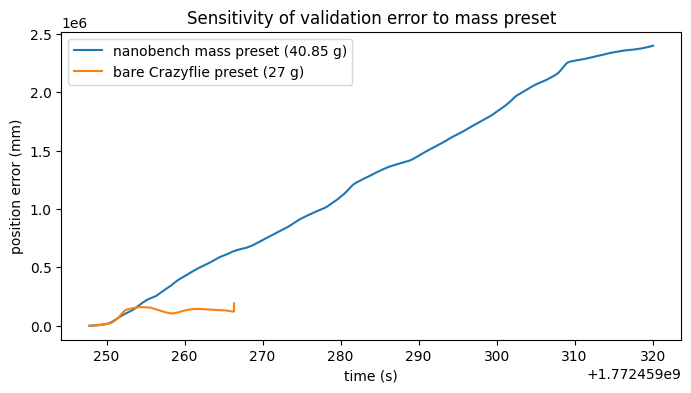

In [25]:
# %% [Cell 8] (Optional) Compare bare vs nanobench mass preset side by side
# ------------------------------------------------------------
sim_bare = phys.simulate_open_loop(cmd_sequence, dt, initial_state,
                                    phys.PARAMS_BARE, U_bat_sequence=vbat)
pos_err_bare = np.linalg.norm(sim_bare["p_WB"] - p_gt, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(t, pos_err * 1000, label="nanobench mass preset (40.85 g)")
plt.plot(t, pos_err_bare * 1000, label="bare Crazyflie preset (27 g)")
plt.ylabel("position error (mm)")
plt.xlabel("time (s)")
plt.legend()
plt.title("Sensitivity of validation error to mass preset")
plt.show()